In [1]:
# ============================================================
# Diabetes Risk Prediction
# Production Training Pipeline
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_predict
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.neural_network import MLPClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve
)

SEED = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# Load Dataset
# ============================================================

DATA_PATH = "../data/train.csv"

data = pd.read_csv(DATA_PATH)

TARGET = "diagnosed_diabetes"

X = data.drop(columns=[TARGET, "id"])

y = data[TARGET]

print(f"Dataset Shape : {data.shape}")
print(f"Features      : {X.shape[1]}")
print(f"Target        : {TARGET}")

Dataset Shape : (700000, 26)
Features      : 24
Target        : diagnosed_diabetes


In [3]:
# ============================================================
# Train/Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=SEED

)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

Training Samples : 560000
Testing Samples  : 140000


In [4]:
# ============================================================
# Build Preprocessing Pipeline
# ============================================================

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns

numeric_transformer = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="median")),

        ("scaler", StandardScaler())

    ]

)

categorical_transformer = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="most_frequent")),

        ("encoder", OneHotEncoder(handle_unknown="ignore"))

    ]

)

preprocessor = ColumnTransformer(

    transformers=[

        ("num", numeric_transformer, numeric_features),

        ("cat", categorical_transformer, categorical_features)

    ]

)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [5]:
# ============================================================
# Fit Preprocessor and Transform Data
# ============================================================

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print(f"Processed Training Shape : {X_train_processed.shape}")
print(f"Processed Testing Shape  : {X_test_processed.shape}")

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=SEED

)

Processed Training Shape : (560000, 42)
Processed Testing Shape  : (140000, 42)


In [6]:
# ============================================================
# Train Optimized XGBoost
# ============================================================

best_xgb = XGBClassifier(

    n_estimators=433,
    max_depth=4,
    learning_rate=0.17453165042833232,
    subsample=0.9704946951067844,
    colsample_bytree=0.7817145825646337,
    min_child_weight=10,
    gamma=1.1001254585090818,
    reg_alpha=1.9317588390134475,
    reg_lambda=4.216150917952283,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=SEED,
    n_jobs=-1

)

best_xgb.fit(
    X_train_processed,
    y_train
)

print("✓ Optimized XGBoost trained successfully.")

✓ Optimized XGBoost trained successfully.


In [7]:
# ============================================================
# Train Optimized LightGBM
# ============================================================

best_lgb = LGBMClassifier(

    n_estimators=455,
    learning_rate=0.11212631308807823,
    max_depth=6,
    num_leaves=40,
    min_child_samples=54,
    subsample=0.7799882309499114,
    colsample_bytree=0.6467555395453211,
    reg_alpha=4.580510006186321,
    reg_lambda=3.9510367337887597,

    random_state=SEED,
    n_jobs=-1,
    verbose=-1

)

best_lgb.fit(
    X_train_processed,
    y_train
)

print("✓ Optimized LightGBM trained successfully.")

✓ Optimized LightGBM trained successfully.


In [8]:
# ============================================================
# Train Optimized Multi-Layer Perceptron
# ============================================================

best_mlp = MLPClassifier(

    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.0005,
    batch_size=512,
    learning_rate="adaptive",
    learning_rate_init=0.001,
    max_iter=300,
    shuffle=True,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=15,

    random_state=SEED

)

best_mlp.fit(
    X_train_processed,
    y_train
)

print("✓ Optimized MLP trained successfully.")

✓ Optimized MLP trained successfully.


In [9]:
# ============================================================
# Generate Out-of-Fold Meta Features
# ============================================================

xgb_oof = cross_val_predict(
    best_xgb,
    X_train_processed,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

lgb_oof = cross_val_predict(
    best_lgb,
    X_train_processed,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

mlp_oof = cross_val_predict(
    best_mlp,
    X_train_processed,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

meta_X_train = pd.DataFrame({

    "XGB": xgb_oof,
    "LGBM": lgb_oof,
    "MLP": mlp_oof

})

meta_X_test = pd.DataFrame({

    "XGB": best_xgb.predict_proba(X_test_processed)[:, 1],
    "LGBM": best_lgb.predict_proba(X_test_processed)[:, 1],
    "MLP": best_mlp.predict_proba(X_test_processed)[:, 1]

})

print("✓ Meta features generated successfully.")

✓ Meta features generated successfully.


In [10]:
# ============================================================
# Train Logistic Regression Meta Learner
# ============================================================

meta_model = LogisticRegression(

    C=100,
    solver="lbfgs",
    max_iter=2000,
    random_state=SEED

)

meta_model.fit(
    meta_X_train,
    y_train
)

print("✓ Meta Learner trained successfully.")

✓ Meta Learner trained successfully.


In [11]:
# ============================================================
# Probability Calibration
# ============================================================

calibrated_model = CalibratedClassifierCV(

    estimator=meta_model,

    method="isotonic",

    cv=5

)

calibrated_model.fit(

    meta_X_train,

    y_train

)

print("✓ Probability calibration completed.")

✓ Probability calibration completed.


In [12]:
# ============================================================
# Threshold Optimization
# ============================================================

final_probs = calibrated_model.predict_proba(

    meta_X_test

)[:, 1]

precision_curve, recall_curve, thresholds = precision_recall_curve(

    y_test,

    final_probs

)

f1_scores = (

    2 * precision_curve[:-1] * recall_curve[:-1]

) / (

    precision_curve[:-1] + recall_curve[:-1] + 1e-8

)

best_threshold = thresholds[np.argmax(f1_scores)]

final_preds = (final_probs >= best_threshold).astype(int)

print(f"Optimal Decision Threshold : {best_threshold:.6f}")

Optimal Decision Threshold : 0.382094


In [13]:
# ============================================================
# Final Evaluation
# ============================================================

roc = roc_auc_score(y_test, final_probs)

precision = precision_score(y_test, final_preds)

recall = recall_score(y_test, final_preds)

f1 = f1_score(y_test, final_preds)

balanced_acc = balanced_accuracy_score(y_test, final_preds)

mcc = matthews_corrcoef(y_test, final_preds)

kappa = cohen_kappa_score(y_test, final_preds)

print("=" * 60)
print("Production Stacking Ensemble Performance")
print("=" * 60)

print(f"ROC-AUC            : {roc:.5f}")
print(f"Precision          : {precision:.5f}")
print(f"Recall             : {recall:.5f}")
print(f"F1-Score           : {f1:.5f}")
print(f"Balanced Accuracy  : {balanced_acc:.5f}")
print(f"Matthews Corrcoef  : {mcc:.5f}")
print(f"Cohen's Kappa      : {kappa:.5f}")

Production Stacking Ensemble Performance
ROC-AUC            : 0.72763
Precision          : 0.66635
Recall             : 0.94520
F1-Score           : 0.78165
Balanced Accuracy  : 0.58106
Matthews Corrcoef  : 0.24543
Cohen's Kappa      : 0.18784


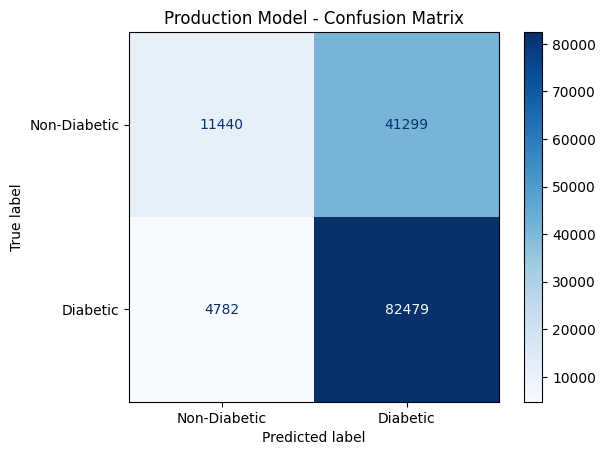

In [14]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(

    y_test,

    final_preds

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["Non-Diabetic", "Diabetic"]

)

disp.plot(cmap="Blues")

plt.title("Production Model - Confusion Matrix")

plt.show()

In [18]:
# ============================================================
# Export Production Artifacts
# ============================================================

import os
import joblib

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# ------------------------------------------------------------
# Save Preprocessor
# ------------------------------------------------------------
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

# ------------------------------------------------------------
# Save Optimized Base Models
# ------------------------------------------------------------
joblib.dump(
    best_xgb,
    "../models/xgb.pkl"
)

joblib.dump(
    best_lgb,
    "../models/lightgbm.pkl"
)

joblib.dump(
    best_mlp,
    "../models/mlp.pkl"
)

# ------------------------------------------------------------
# Save Meta Learner
# ------------------------------------------------------------
joblib.dump(
    meta_model,
    "../models/meta.pkl"
)

# ------------------------------------------------------------
# Save Calibrated Model
# ------------------------------------------------------------
joblib.dump(
    calibrated_model,
    "../models/calibrated.pkl"
)

# ------------------------------------------------------------
# Save Optimal Threshold
# ------------------------------------------------------------
joblib.dump(
    best_threshold,
    "../models/threshold.pkl"
)

# ------------------------------------------------------------
# Save Feature Order
# ------------------------------------------------------------
feature_names = X.columns.tolist()

joblib.dump(
    feature_names,
    "../models/feature_names.pkl"
)

# ------------------------------------------------------------
# Save Target Labels
# ------------------------------------------------------------
target_labels = {
    0: "Non-Diabetic",
    1: "Diabetic"
}

joblib.dump(
    target_labels,
    "../models/target_labels.pkl"
)

print("=" * 60)
print("Production artifacts exported successfully.")
print("=" * 60)

print("Saved Files:")
print("✔ preprocessor.pkl")
print("✔ xgb.pkl")
print("✔ lightgbm.pkl")
print("✔ mlp.pkl")
print("✔ meta.pkl")
print("✔ calibrated.pkl")
print("✔ threshold.pkl")
print("✔ feature_names.pkl")
print("✔ target_labels.pkl")
print("=" * 60)

Production artifacts exported successfully.
Saved Files:
✔ preprocessor.pkl
✔ xgb.pkl
✔ lightgbm.pkl
✔ mlp.pkl
✔ meta.pkl
✔ calibrated.pkl
✔ threshold.pkl
✔ feature_names.pkl
✔ target_labels.pkl
